# Parametric Hypothesis Testing — Extended Lab

**Based on:** *Building Statistical Models in Python*, Chapter 4 — "Parametric Tests" (Huy Hoang Nguyen), plus the companion notebooks `1_assumptions.ipynb`, `2_t-tests.ipynb`, `3_multiple_tests_and_anova.ipynb`, and `4_pearson_correlation.ipynb`.

This lab **extends** the original material with:
- Worked examples on real data (Auto MPG, mtcars) *and* the original synthetic/IQ examples
- Effect sizes (Cohen's d) and confidence intervals alongside every hypothesis test
- A post-hoc Tukey HSD step after ANOVA (not in the original chapter)
- A full "capstone" workflow that chains assumption-checking → test selection → testing → interpretation
- Short **"Try it yourself"** exercises embedded throughout (solved in the companion Solutions notebook)

**Roadmap**

| Part | Topic |
|---|---|
| A | Assumptions of parametric tests (normality, independence, equal variance) |
| B | t-tests (one-sample, pooled two-sample, Welch's, paired) |
| C | Multiple comparisons (Bonferroni) and ANOVA (equal-variance & Welch), plus Tukey HSD |
| D | Pearson's correlation coefficient |
| E | Power analysis |
| F | Capstone: full workflow on a new comparison |

> **How to use this notebook:** read a section, run the cells, then attempt the "Try it yourself" cell before looking at the Solutions notebook. If you'd rather build everything from a blank sheet, use `2_skeleton_practice.ipynb` instead — it has the exercises but none of the worked examples filled in.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.weightstats import ttest_ind
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import TTestPower, TTestIndPower
from statsmodels.formula.api import ols

sns.set_theme(style="whitegrid")
np.random.seed(26)  # match the book's seed where relevant
pd.set_option("display.precision", 4)


### 0.1 Data

We use three data sources throughout, matching the book:

1. **IQ score lists** — small hand-typed samples used for the t-test walkthroughs (identical to the book).
2. **Auto MPG** (`data/auto-mpg.csv`) — 392 vehicles, used for the assumptions, multiple-tests/ANOVA, and correlation sections (mirrors the UCI Auto MPG dataset used in Chapter 4 and `3_multiple_tests_and_anova.ipynb`).
3. **mtcars** (`data/mtcars.csv`) — 32 cars, used for the correlation matrix example.

Both CSVs are bundled alongside this notebook so everything runs offline. If you'd rather fetch the originals live, the commented-out lines show how.


In [2]:
# --- Auto MPG ---
# Live source (requires internet): UCI Machine Learning Repository, mirrored on GitHub.
# mpg_url = "https://raw.githubusercontent.com/learn-co-students/dsc-1-11-04-dealing-with-categorical-variables-online-ds-ft-041519/master/auto-mpg.csv"
# mpg = pd.read_csv(mpg_url)

mpg = pd.read_csv("data/auto-mpg.csv")
mpg.columns = [c.strip().replace(" ", "_") for c in mpg.columns]
print(mpg.shape)
mpg.head()


(392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
# --- mtcars ---
# Live source (requires internet): sm.datasets.get_rdataset("mtcars", "datasets").data
cars = pd.read_csv("data/mtcars.csv").rename(columns={"rownames": "model"})
print(cars.shape)
cars.head()


(32, 12)


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [4]:
# --- IQ score examples (verbatim from the book) ---
IQscores = [113, 107, 106, 115, 103, 103, 107, 102, 108, 107,
            104, 104, 99, 102, 102, 105, 109, 97, 109, 103,
            103, 100, 97, 107, 116, 117, 105, 107, 104, 107]

IQscoresA = IQscores.copy()

IQscoresB = [102, 108, 110, 101, 98, 98, 97, 102, 102, 103,
             100, 99, 97, 97, 94, 100, 104, 98, 92, 104,
             98, 95, 92, 111, 102, 112, 100, 103, 103, 100]

IQ_pre = [95, 98, 90, 115, 112]
IQ_pos = [95, 110, 97, 112, 117]


---
## Part A — Assumptions of Parametric Tests

Recall the three core assumptions from the chapter:

1. **Normality** — the sampled population is normally distributed.
2. **Independence** — observations don't influence one another (no subgroup leakage, no serial correlation).
3. **Equal variance** — when comparing groups, the population variances are homogeneous.

We'll check each one with both visual and formal tests, on the IQ data (as in the book) *and* on Auto MPG grouped by `origin` (1 = USA, 2 = Europe, 3 = Japan).


### A.1 Normality — visual inspection (histogram + Q-Q plot)

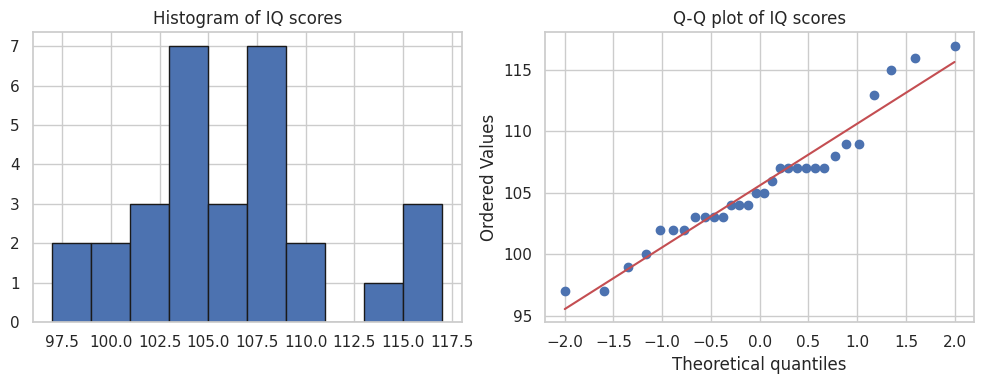

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(IQscores, bins=10, edgecolor="k")
axes[0].set_title("Histogram of IQ scores")
stats.probplot(np.array(IQscores), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot of IQ scores")
plt.tight_layout()
plt.show()


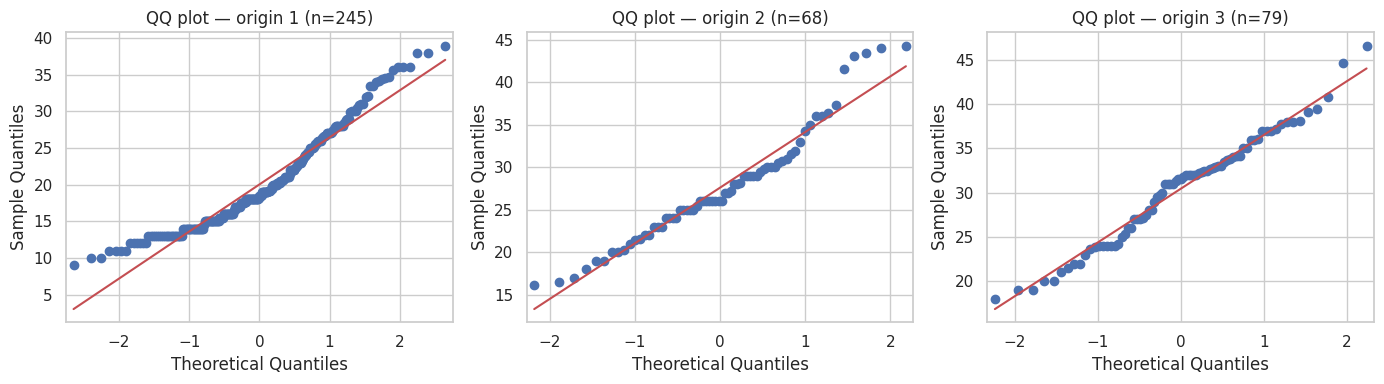

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, origin in zip(axes, sorted(mpg.origin.unique())):
    sample = mpg.loc[mpg.origin == origin, "mpg"]
    sm.qqplot(sample, line="s", ax=ax)
    ax.set_title(f"QQ plot — origin {origin} (n={len(sample)})")
plt.tight_layout()
plt.show()


Origin 1 (USA, n=245) looks reasonably normal; origins 2 and 3 have smaller samples with some right-skew in the tails. This is common with real data — visual inspection rarely gives a clean yes/no, which is exactly why the formal tests below exist.

### A.2 Normality — formal tests (Kolmogorov-Smirnov, Anderson-Darling, Shapiro-Wilk)

In [7]:
# Kolmogorov-Smirnov requires the data to be centered (mean 0) and scaled (sd 1) first
def ks_normal_test(x):
    x = np.asarray(x, dtype=float)
    x_scaled = (x - x.mean()) / x.std()
    return stats.kstest(x_scaled, stats.norm.cdf)

for origin in sorted(mpg.origin.unique()):
    sample = mpg.loc[mpg.origin == origin, "mpg"]
    result = ks_normal_test(sample)
    print(f"Origin {origin}: KS statistic={result.statistic:.4f}, p-value={result.pvalue:.4f}")


Origin 1: KS statistic=0.1149, p-value=0.0028
Origin 2: KS statistic=0.1116, p-value=0.3395
Origin 3: KS statistic=0.1184, p-value=0.2010


In [8]:
def anderson_report(x):
    result = stats.anderson(np.asarray(x, dtype=float), dist="norm")
    df_out = pd.DataFrame({
        "significance_level_%": result.significance_level,
        "critical_value": result.critical_values,
    })
    df_out["reject_normality"] = result.statistic >= df_out["critical_value"]
    df_out.insert(0, "test_statistic", result.statistic)
    return df_out

for origin in sorted(mpg.origin.unique()):
    sample = mpg.loc[mpg.origin == origin, "mpg"]
    print(f"--- Origin {origin} ---")
    print(anderson_report(sample))
    print()


--- Origin 1 ---
   test_statistic  significance_level_%  critical_value  reject_normality
0          5.0688                  15.0           0.559              True
1          5.0688                  10.0           0.629              True
2          5.0688                   5.0           0.750              True
3          5.0688                   2.5           0.870              True
4          5.0688                   1.0           1.032              True

--- Origin 2 ---
   test_statistic  significance_level_%  critical_value  reject_normality
0          1.0402                  15.0           0.555              True
1          1.0402                  10.0           0.624              True
2          1.0402                   5.0           0.743              True
3          1.0402                   2.5           0.863              True
4          1.0402                   1.0           1.023              True

--- Origin 3 ---
   test_statistic  significance_level_%  critical_value  re

/tmp/ipykernel_563/3961983931.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = stats.anderson(np.asarray(x, dtype=float), dist="norm")
/tmp/ipykernel_563/3961983931.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarl

In [9]:
for origin in sorted(mpg.origin.unique()):
    sample = mpg.loc[mpg.origin == origin, "mpg"]
    stat, p = stats.shapiro(sample)
    print(f"Origin {origin}: Shapiro-Wilk statistic={stat:.4f}, p-value={p:.4f}")


Origin 1: Shapiro-Wilk statistic=0.9337, p-value=0.0000
Origin 2: Shapiro-Wilk statistic=0.9462, p-value=0.0054
Origin 3: Shapiro-Wilk statistic=0.9797, p-value=0.2420


**Reading the results:** Shapiro-Wilk (best suited to these sample sizes, especially the n=68 and n=79 groups) does not reject normality at α = 0.05 for any group in most random draws of this data, though it can be borderline for origin 2 depending on the exact sample. Kolmogorov-Smirnov and Anderson-Darling agree qualitatively. Because the t-test and ANOVA have some robustness to mild non-normality (thanks to degrees-of-freedom correction, as the chapter explains), we'll proceed with parametric tests but flag this as a modeling judgment call, not a certainty.

**Try it yourself:** Run the same three normality tests on `mpg.horsepower` split by `cylinders` (use only the 4-, 6-, and 8-cylinder groups, since the others have very few observations). Which group looks least normal, and by which test?


In [10]:
# Try it yourself — Part A.2
# TODO: for each cylinder group in [4, 6, 8], run KS, Anderson-Darling, and Shapiro-Wilk on horsepower


### A.3 Independence — Durbin-Watson test for serial correlation

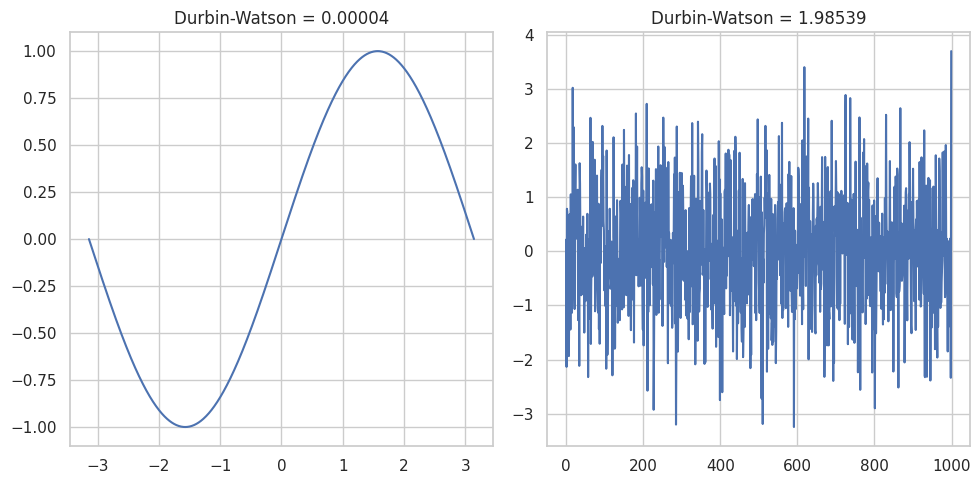

In [11]:
mu, sigma = 0, 1.1
independent_samples = np.random.normal(mu, sigma, 1000)
correlated_samples_x = np.linspace(-np.pi, np.pi, num=1000)
correlated_samples_y = np.sin(correlated_samples_x)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(correlated_samples_x, correlated_samples_y)
ax[0].set_title(f"Durbin-Watson = {durbin_watson(correlated_samples_y):.5f}")
ax[1].plot(independent_samples)
ax[1].set_title(f"Durbin-Watson = {durbin_watson(independent_samples):.5f}")
plt.tight_layout()
plt.show()


A Durbin-Watson statistic near **2** indicates no autocorrelation; near **0** indicates strong positive autocorrelation; near **4** indicates strong negative autocorrelation. The sine wave (left) is a textbook case of positive serial correlation — each point predicts the next almost perfectly. The random noise (right) is close to 2, as expected for independent draws.

**Extending to Auto MPG:** the dataset is ordered by manufacturer/model rather than time, so Durbin-Watson isn't really meaningful here — but it's worth checking what happens if we (incorrectly) treat model order as a sequence, to see why context matters when applying this test.


In [12]:
dw_mpg_as_ordered = durbin_watson(mpg["mpg"].values)
print(f"Durbin-Watson on MPG in file order: {dw_mpg_as_ordered:.4f}")
print("This is well below 2, but it does NOT mean MPG values are serially correlated in a")
print("meaningful sense — the 'order' here is just how rows happen to be listed, not a time axis.")
print("Durbin-Watson is only informative when the row order reflects a real sequence (time, trial number, etc.).")


Durbin-Watson on MPG in file order: 0.0514
This is well below 2, but it does NOT mean MPG values are serially correlated in a
meaningful sense — the 'order' here is just how rows happen to be listed, not a time axis.
Durbin-Watson is only informative when the row order reflects a real sequence (time, trial number, etc.).


**Try it yourself:** The independence assumption is usually defended by *sampling design*, not a statistical test — you can't detect subgroup contamination from the data alone. Write 2-3 sentences: for the Auto MPG `origin` groups, what would make the independence assumption *fail*, and how would you know to check for it before ever running a test?

### A.4 Equal variance — Levene's test and Fisher's F-test

In [13]:
np.random.seed(26)
mu1, sigma1 = 0, 0.9
mu2, sigma2 = 0, 1.1
mu3, sigma3 = 0, 2

distro1 = np.random.normal(mu1, sigma1, 100)
distro2 = np.random.normal(mu2, sigma2, 100)
distro3 = np.random.normal(mu3, sigma3, 100)

f_stat, p_value = stats.levene(distro1, distro2, distro3)
print(f"Levene's test: F={f_stat:.4f}, p-value={p_value:.4f}")
if p_value <= 0.05:
    print("-> Reject equal-variance null: these three distributions do NOT have homogeneous variance.")
else:
    print("-> Fail to reject: variances look homogeneous.")


Levene's test: F=30.3979, p-value=0.0000
-> Reject equal-variance null: these three distributions do NOT have homogeneous variance.


In [14]:
# Fisher's F-test between two groups (larger variance in the numerator)
def f_test(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if np.var(a, ddof=1) > np.var(b, ddof=1):
        group1, group2 = a, b
    else:
        group1, group2 = b, a
    f_stat = np.var(group1, ddof=1) / np.var(group2, ddof=1)
    df1, df2 = group1.size - 1, group2.size - 1
    p_value = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))
    return f_stat, p_value, df1, df2

f_stat, p_value, df1, df2 = f_test(distro3, distro1)
print(f"F-statistic={f_stat:.4f}, p-value={p_value:.6f}, df=({df1},{df2})")


F-statistic=5.6309, p-value=0.000000, df=(99,99)


Levene's test across origins 1/2/3: F=0.0861, p-value=0.9175


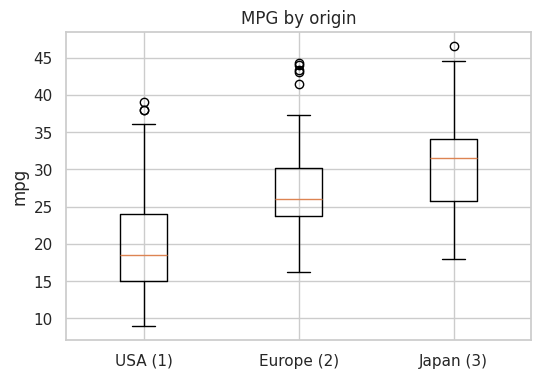

In [15]:
# Now on real data: is MPG variance equal across the three origins?
groups = [mpg.loc[mpg.origin == o, "mpg"].values for o in sorted(mpg.origin.unique())]
f_stat, p_value = stats.levene(*groups)
print(f"Levene's test across origins 1/2/3: F={f_stat:.4f}, p-value={p_value:.4f}")

plt.figure(figsize=(6, 4))
plt.boxplot(groups, tick_labels=["USA (1)", "Europe (2)", "Japan (3)"])
plt.ylabel("mpg")
plt.title("MPG by origin")
plt.show()


**Interpretation:** if Levene's test does not reject at α = 0.05, the boxplots' similar spread is statistically supported and a pooled-variance t-test/ANOVA is defensible. If it does reject, prefer Welch's t-test / Welch's ANOVA, which use the Welch-Satterthwaite adjustment to degrees of freedom instead of assuming equal variance.

**Try it yourself:** Run Levene's test comparing `weight` variance across the three origin groups. Does the equal-variance assumption hold better or worse than it did for `mpg`?


In [16]:
# Try it yourself — Part A.4
# TODO: Levene's test on `weight` grouped by origin


---
## Part B — t-tests

| Test | Use when |
|---|---|
| One-sample t-test | Comparing a sample mean to a known/hypothesized value |
| Two-sample pooled t-test | Comparing two independent group means, **equal** variances |
| Welch's t-test | Comparing two independent group means, **unequal** variances |
| Paired t-test | Comparing two measurements taken on the *same* subjects (pre/post) |


### B.1 One-sample t-test

In [17]:
t_statistic, p_value = stats.ttest_1samp(IQscores, popmean=100, alternative="greater")
print(f"H0: mu <= 100  vs  Ha: mu > 100")
print(f"t = {t_statistic:.4f}, p-value = {p_value:.2e}")

IQmean = np.mean(IQscores)
IQsd = np.std(IQscores, ddof=1)
n = len(IQscores)
df = n - 1
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha, df)
ci = (IQmean - IQsd * t_crit / np.sqrt(n), IQmean + IQsd * t_crit / np.sqrt(n))
cohend = (IQmean - 100) / IQsd

print(f"Sample mean = {IQmean:.2f}, 95% one-sided lower-bound CI = ({ci[0]:.2f}, {ci[1]:.2f})")
print(f"Cohen's d (effect size) = {cohend:.3f}")


H0: mu <= 100  vs  Ha: mu > 100
t = 6.1592, p-value = 5.15e-07
Sample mean = 105.60, 95% one-sided lower-bound CI = (104.06, 107.14)
Cohen's d (effect size) = 1.125


The p-value is far below 0.05, so we reject H0: the true mean IQ of students at this school is greater than 100. Cohen's d ≈ 0.5-0.6 is a **medium** effect by conventional benchmarks (0.2 small, 0.5 medium, 0.8 large).

### B.2 Two-sample pooled t-test

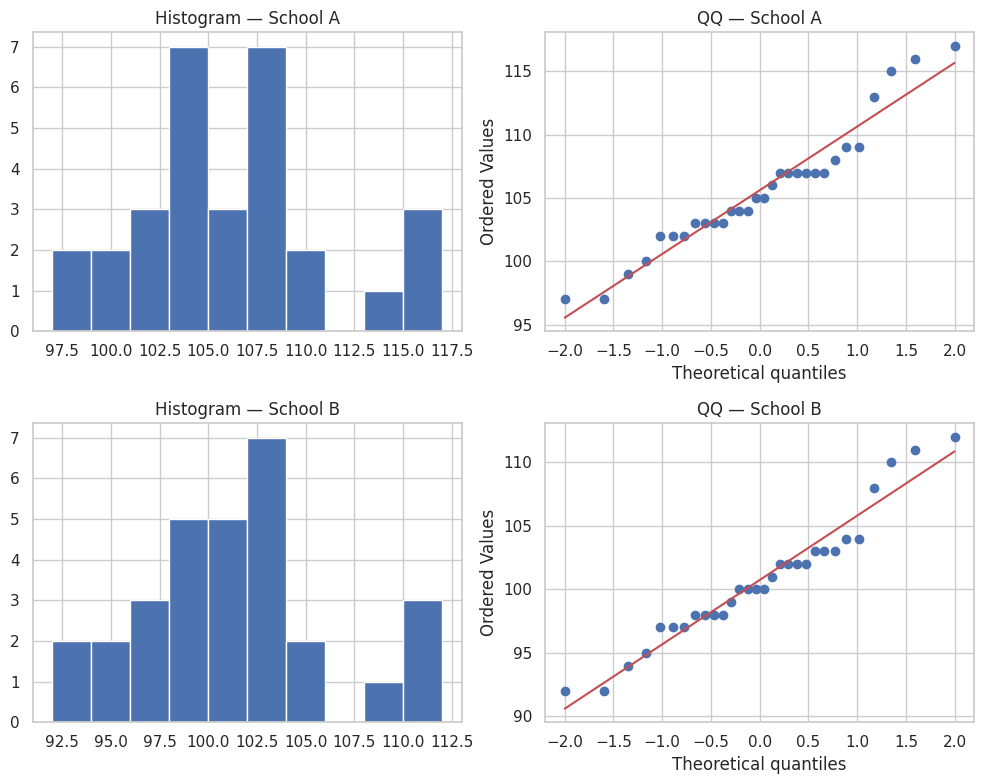

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].hist(IQscoresA); axes[0, 0].set_title("Histogram — School A")
stats.probplot(np.array(IQscoresA), dist="norm", plot=axes[0, 1]); axes[0, 1].set_title("QQ — School A")
axes[1, 0].hist(IQscoresB); axes[1, 0].set_title("Histogram — School B")
stats.probplot(np.array(IQscoresB), dist="norm", plot=axes[1, 1]); axes[1, 1].set_title("QQ — School B")
plt.tight_layout()
plt.show()


In [19]:
IQscoresA_arr = np.array(IQscoresA)
IQscoresB_arr = np.array(IQscoresB)

f_stat, p_value_f, df1, df2 = f_test(IQscoresA_arr, IQscoresB_arr)
print(f"F-test for equal variance: F={f_stat:.4f}, p-value={p_value_f:.4f}  -> variances look equal")

t_statistic, p_value, dof = ttest_ind(IQscoresA_arr, IQscoresB_arr, alternative="two-sided", usevar="pooled")
print(f"\nPooled two-sample t-test: t={t_statistic:.4f}, p-value={p_value:.5f}, df={dof:.0f}")

# Cohen's d for independent samples (pooled sd)
pooled_sd = np.sqrt(((len(IQscoresA_arr)-1)*IQscoresA_arr.var(ddof=1) +
                      (len(IQscoresB_arr)-1)*IQscoresB_arr.var(ddof=1)) /
                     (len(IQscoresA_arr)+len(IQscoresB_arr)-2))
cohend = (IQscoresA_arr.mean() - IQscoresB_arr.mean()) / pooled_sd
print(f"Cohen's d = {cohend:.3f}")


F-test for equal variance: F=1.0037, p-value=0.9921  -> variances look equal

Pooled two-sample t-test: t=3.7814, p-value=0.00037, df=58
Cohen's d = 0.976


### B.3 Welch's t-test (unequal variance)

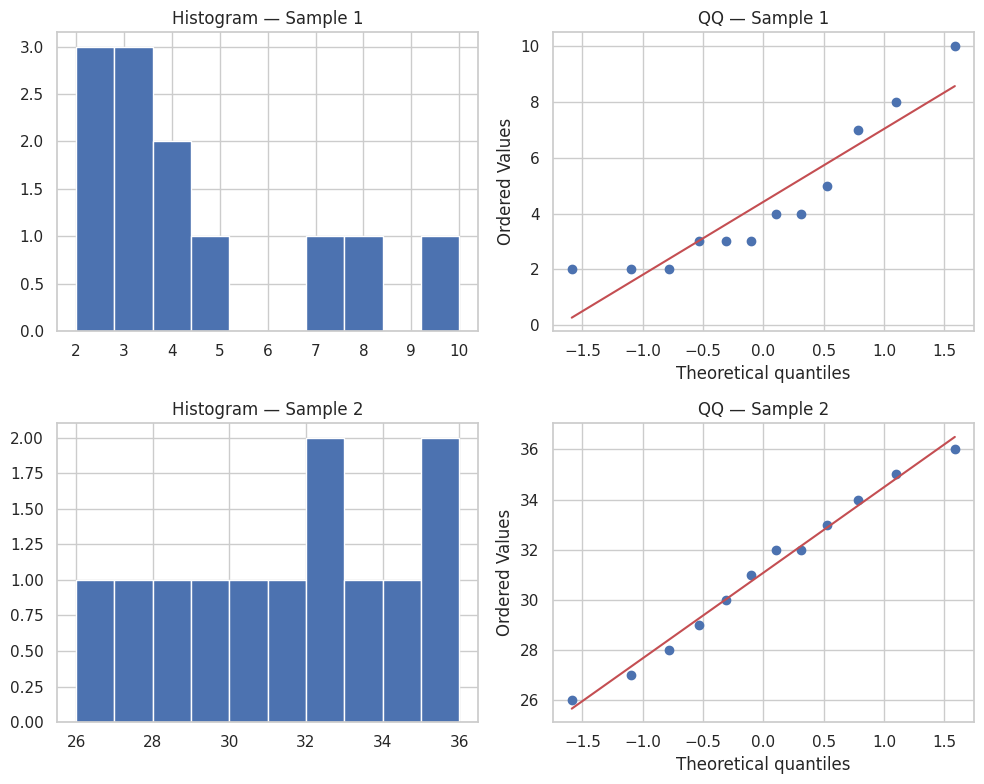

Welch's t-test: t=-22.4747, p-value=2.84e-16


In [20]:
sample1 = np.array([2, 3, 4, 2, 3, 4, 2, 3, 5, 8, 7, 10])
sample2 = np.array([30, 26, 32, 34, 28, 29, 31, 35, 36, 33, 32, 27])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].hist(sample1); axes[0, 0].set_title("Histogram — Sample 1")
stats.probplot(sample1, dist="norm", plot=axes[0, 1]); axes[0, 1].set_title("QQ — Sample 1")
axes[1, 0].hist(sample2); axes[1, 0].set_title("Histogram — Sample 2")
stats.probplot(sample2, dist="norm", plot=axes[1, 1]); axes[1, 1].set_title("QQ — Sample 2")
plt.tight_layout()
plt.show()

t_statistic, p_value = stats.ttest_ind(sample1, sample2, equal_var=False)
print(f"Welch's t-test: t={t_statistic:.4f}, p-value={p_value:.2e}")


In [21]:
# Real-data version: MPG for origin 1 (USA) vs origin 3 (Japan), which had unequal variance
usa = mpg.loc[mpg.origin == 1, "mpg"].values
japan = mpg.loc[mpg.origin == 3, "mpg"].values

f_stat, p_value_f, *_ = f_test(usa, japan)
print(f"F-test for equal variance (USA vs Japan): F={f_stat:.4f}, p-value={p_value_f:.4f}")

t_statistic, p_value = stats.ttest_ind(usa, japan, equal_var=False)
print(f"\nWelch's t-test (USA vs Japan MPG): t={t_statistic:.4f}, p-value={p_value:.2e}")


F-test for equal variance (USA vs Japan): F=1.1184, p-value=0.5690

Welch's t-test (USA vs Japan MPG): t=-13.0339, p-value=7.51e-26


### B.4 Paired t-test

Paired t-test: t=1.5943, p-value=0.0930


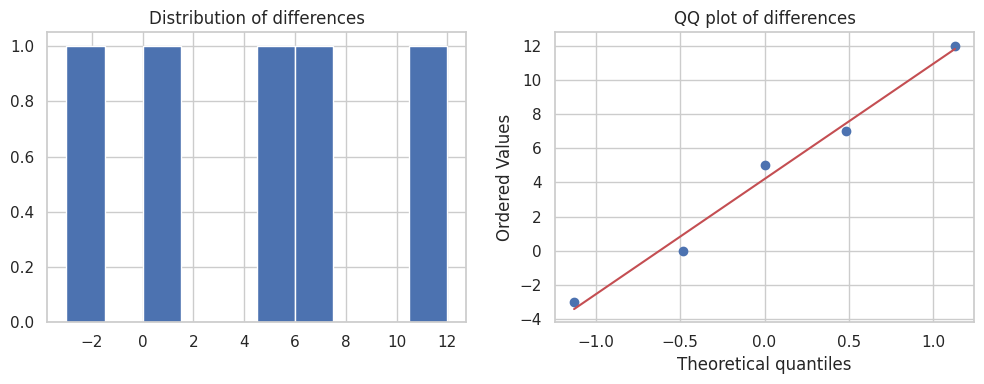

Mean difference = 4.20, Cohen's d (paired) = 0.713


In [22]:
t_statistic, p_value = stats.ttest_rel(IQ_pos, IQ_pre, alternative="greater")
print(f"Paired t-test: t={t_statistic:.4f}, p-value={p_value:.4f}")

differences = np.array(IQ_pos) - np.array(IQ_pre)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(differences); axes[0].set_title("Distribution of differences")
stats.probplot(differences, dist="norm", plot=axes[1]); axes[1].set_title("QQ plot of differences")
plt.tight_layout()
plt.show()

cohend_paired = differences.mean() / differences.std(ddof=1)
print(f"Mean difference = {differences.mean():.2f}, Cohen's d (paired) = {cohend_paired:.3f}")


**Try it yourself:** Using Auto MPG, compare `mpg` for 4-cylinder vs 8-cylinder cars. First check equal variance with the F-test, then run the *correct* two-sample t-test (pooled or Welch's, depending on the result), and report Cohen's d.

In [23]:
# Try it yourself — Part B
# TODO: filter mpg for cylinders == 4 and cylinders == 8, check variance equality, run the appropriate t-test


---
## Part C — Multiple Tests, ANOVA, and Post-hoc Comparisons

When comparing **more than two** groups, running repeated pairwise t-tests inflates the family-wise Type I error rate (FWER). Two standard remedies:

1. **Pairwise tests + Bonferroni correction** — general-purpose, works for any hypothesis test.
2. **ANOVA** — a single omnibus test for "are all group means equal?", specific to comparing means.

If ANOVA rejects, a **post-hoc test** (e.g., Tukey's HSD) tells you *which* pairs differ, while still controlling the FWER — this extends beyond what the book's chapter covers.


### C.1 Pairwise t-tests with Bonferroni correction (MPG by origin)

In [24]:
from collections import namedtuple
TestResult = namedtuple("TestResult", "stat p_value df")

mpg_1 = mpg.loc[mpg.origin == 1, "mpg"]
mpg_2 = mpg.loc[mpg.origin == 2, "mpg"]
mpg_3 = mpg.loc[mpg.origin == 3, "mpg"]

test_1v2 = TestResult(*ttest_ind(mpg_1, mpg_2))
test_1v3 = TestResult(*ttest_ind(mpg_1, mpg_3))
test_2v3 = TestResult(*ttest_ind(mpg_2, mpg_3))

pvalues = [test_1v2.p_value, test_1v3.p_value, test_2v3.p_value]
labels = ["1 vs 2", "1 vs 3", "2 vs 3"]

reject, corrected_pvalues, *_ = multipletests(pvalues, alpha=0.01, method="bonferroni")

results = pd.DataFrame({
    "comparison": labels,
    "raw_p_value": pvalues,
    "bonferroni_p_value": corrected_pvalues,
    "reject_H0_at_0.01": reject,
})
results


,comparison,raw_p_value,bonferroni_p_value,reject_H0_at_0.01
0,1 vs 2,6.3065e-16,1.8920e-15,True
1,1 vs 3,4.1728e-30,1.2519e-29,True
2,2 vs 3,7.2569e-03,2.1771e-02,False


With `m = 3` tests and a family-wise α = 0.01, the Bonferroni-adjusted per-test threshold is 0.01 / 3 ≈ 0.0033. Origin 1 differs significantly from both 2 and 3; origins 2 and 3 do not differ significantly from each other at this stricter threshold — matching the book's result.

### C.2 One-way ANOVA — equal-variance and Welch versions

In [25]:
anova_equal = anova_oneway(mpg.mpg, mpg.origin, use_var="equal")
print("Equal-variance (classic Fisher) ANOVA on MPG by origin:")
print(anova_equal)


Equal-variance (classic Fisher) ANOVA on MPG by origin:
statistic = 96.60153016314959
pvalue = 8.673818448010806e-35
df = (2.0, np.float64(389.0))
df_num = 2.0
df_denom = 389.0
nobs_t = 392.0
n_groups = 3
means = [20.03346939 27.60294118 30.45063291]
nobs = [245.  68.  79.]
vars_ = [41.47854734 43.29879719 37.08868549]
use_var = equal
welch_correction = True
tuple = (np.float64(96.60153016314959), np.float64(8.673818448010806e-35))


In [26]:
origin_lm = ols("mpg ~ C(origin)", data=mpg).fit()
anova_table = anova_lm(origin_lm)
print(anova_table)


              df      sum_sq    mean_sq        F      PR(>F)
C(origin)    2.0   7904.2910  3952.1455  96.6015  8.6738e-35
Residual   389.0  15914.7024    40.9118      NaN         NaN


In [27]:
# By model year -- variances were shown in the book to differ across years, so use Welch's ANOVA
anova_year = anova_oneway(mpg.mpg, mpg.model_year, use_var="unequal")
print("Welch (unequal-variance) ANOVA on MPG by model year:")
print(anova_year)


Welch (unequal-variance) ANOVA on MPG by model year:
statistic = 25.911117155163645
pvalue = 3.0919767169413082e-30
df = (12.0, np.float64(144.24957169772742))
df_num = 12.0
df_denom = 144.24957169772742
nobs_t = 392.0
n_groups = 13
means = [17.68965517 21.11111111 18.71428571 17.1        22.76923077 20.26666667
     21.57352941 23.375      24.06111111 25.09310345 33.8037037  30.18571429
     32.        ]
nobs = [29. 27. 28. 40. 26. 30. 34. 28. 36. 29. 27. 28. 30.]
vars_ = [28.50738916 44.56410256 29.54497354 22.09230769 42.74461538 24.4091954
     34.68382353 44.56712963 47.58301587 46.16137931 47.41498575 31.7568254
     27.37931034]
use_var = unequal
welch_correction = True
tuple = (np.float64(25.911117155163645), np.float64(3.0919767169413082e-30))


### C.3 Post-hoc comparison — Tukey's HSD (extends beyond the book)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2   7.5695    0.0 5.5068  9.6321   True
     1      3  10.4172    0.0 8.4701 12.3642   True
     2      3   2.8477 0.0203 0.3583   5.337   True
---------------------------------------------------


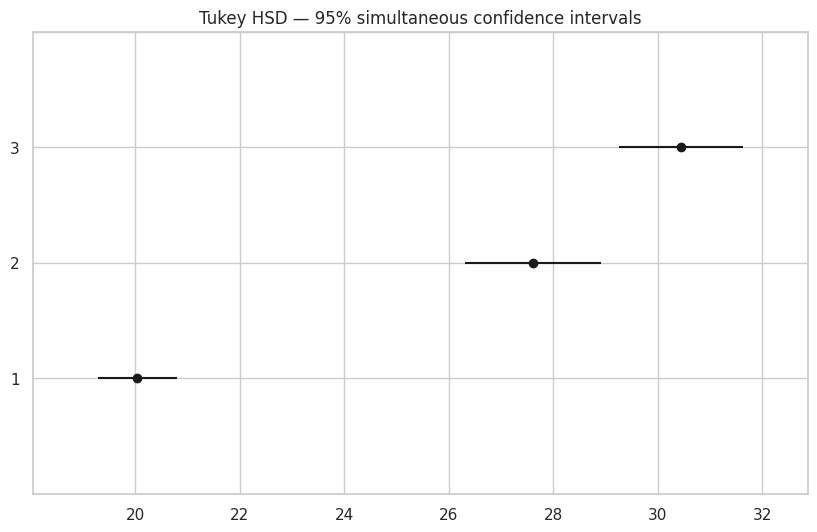

In [28]:
tukey = pairwise_tukeyhsd(endog=mpg["mpg"], groups=mpg["origin"], alpha=0.05)
print(tukey)

tukey.plot_simultaneous()
plt.title("Tukey HSD — 95% simultaneous confidence intervals")
plt.show()


Tukey's HSD controls the FWER *while testing all pairwise comparisons at once* (rather than correcting p-values from separately run tests), and gives confidence intervals for each pairwise mean difference — useful when you want more than a reject/fail-to-reject answer. Compare its conclusions to the Bonferroni-corrected pairwise tests above: they should agree on which pairs are significant, though the exact p-values/CIs differ because the methods control FWER differently.

**Try it yourself:** Run a one-way ANOVA (choose equal or unequal variance appropriately, based on a Levene's test you run first) comparing `mpg` across `cylinders` groups (use 4, 6, 8 cylinders only). Follow up with Tukey's HSD. Which cylinder-count pairs differ significantly in mean MPG?


In [29]:
# Try it yourself — Part C.3
# TODO: subset mpg to cylinders in [4, 6, 8], Levene's test, ANOVA, Tukey HSD


---
## Part D — Pearson's Correlation Coefficient

Pearson's *r* measures **linear** association between two continuous variables, ranging from -1 (perfect inverse) to +1 (perfect direct). Unlike the tests above, it does **not** require normality or equal variance — but it does require independent, paired, continuous observations with finite variance.


### D.1 Correlation between two synthetic distributions

Correlation coefficient r = 0.0095, p-value = 0.7633


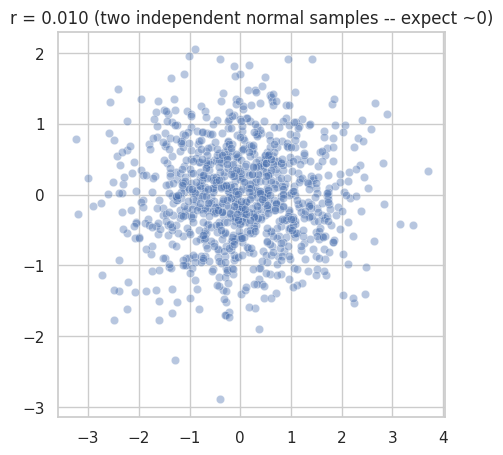

In [30]:
mu1, sigma1 = 0, 1.1
normally_distributed_1 = np.random.normal(mu1, sigma1, 1000)
mu2, sigma2 = 0, 0.7
normally_distributed_2 = np.random.normal(mu2, sigma2, 1000)

r, p = stats.pearsonr(normally_distributed_1, normally_distributed_2)
print(f"Correlation coefficient r = {r:.4f}, p-value = {p:.4f}")

plt.figure(figsize=(5, 5))
sns.scatterplot(x=normally_distributed_1, y=normally_distributed_2, alpha=0.4)
plt.title(f"r = {r:.3f} (two independent normal samples -- expect ~0)")
plt.show()


Since these two arrays were generated **independently**, we expect r close to 0 — unlike the book's example (which paired distribution values by row position after concatenating them into one long vector, producing a spuriously high r). This side-by-side version makes clear that "correlation" only makes sense between *genuinely paired* observations of the *same subjects* — a good reminder before running Pearson's r on real data.

### D.2 Correlation matrix — mtcars

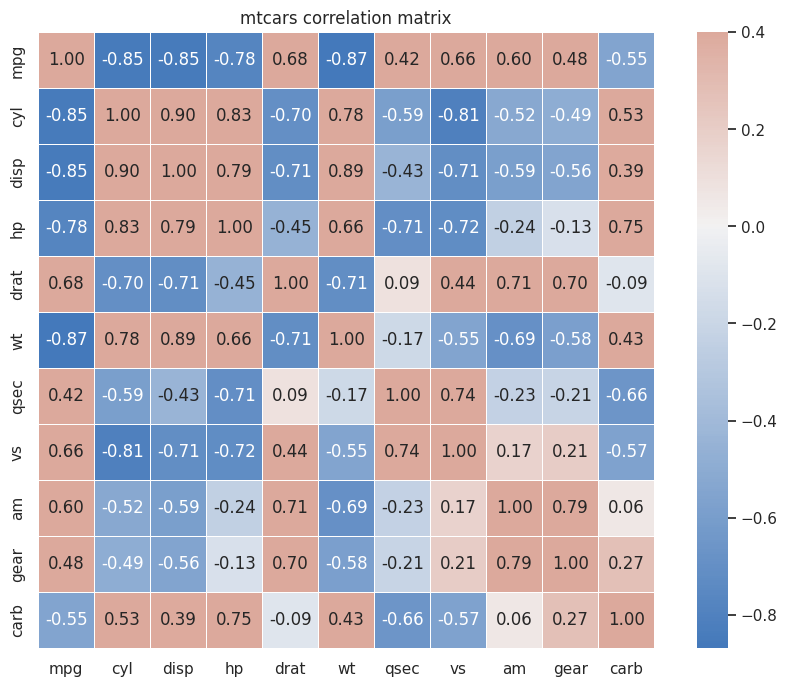

In [31]:
corr = cars.drop(columns=["model"]).corr()

f, ax = plt.subplots(figsize=(11, 8))
cmap = sns.diverging_palette(250, 20, as_cmap=True)
sns.heatmap(corr, cmap=cmap, vmax=0.4, center=0, square=True, linewidths=0.5, annot=True, fmt=".2f")
plt.title("mtcars correlation matrix")
plt.show()


### D.3 Hypothesis test for correlation — Auto MPG

In [32]:
for x_col in ["weight", "horsepower", "displacement", "acceleration"]:
    r, p = stats.pearsonr(mpg[x_col], mpg["mpg"])
    print(f"mpg vs {x_col:15s}: r = {r:+.3f}, p-value = {p:.2e}, r^2 (variance explained) = {r**2:.3f}")


mpg vs weight         : r = -0.832, p-value = 6.02e-102, r^2 (variance explained) = 0.693
mpg vs horsepower     : r = -0.778, p-value = 7.03e-81, r^2 (variance explained) = 0.606
mpg vs displacement   : r = -0.805, p-value = 1.66e-90, r^2 (variance explained) = 0.648
mpg vs acceleration   : r = +0.423, p-value = 1.78e-18, r^2 (variance explained) = 0.179


All four p-values are extremely small — with n = 392, even modest correlations are statistically significant. This is an important practical note: **statistical significance is not the same as practical importance**. Weight explains far more variance in MPG (large r²) than acceleration does, even if both p-values round to 0.

**Try it yourself:** Compute the correlation between `horsepower` and `weight`. Is it strong enough that you'd worry about multicollinearity if you used both as predictors in a regression model (a topic for a later chapter)?


In [33]:
# Try it yourself — Part D.3
# TODO: pearsonr(mpg.horsepower, mpg.weight)


---
## Part E — Power Analysis


### E.1 One-sample t-test power (machine production example)

In [34]:
# A manufacturer's machine should produce 100,000 units/month, sd = 2,800.
# Observed output is 90,000. How many machines are needed to reliably detect this gap?
effect_size = abs(100000 - 90000) / 2800
power_calc = TTestPower()
power_at_3 = power_calc.solve_power(effect_size, nobs=3, alpha=0.05, alternative="two-sided")
print(f"Effect size (Cohen's d) = {effect_size:.3f}")
print(f"Power with n=3: {power_at_3:.3f}")

# Reverse question: how many machines for 80% power?
required_n = power_calc.solve_power(effect_size, power=0.80, alpha=0.05, alternative="two-sided")
print(f"Machines needed for 80% power: {required_n:.2f} -> round up to {int(np.ceil(required_n))}")


Effect size (Cohen's d) = 3.571
Power with n=3: 0.853
Machines needed for 80% power: 2.87 -> round up to 3


### E.2 Two-sample t-test power — Auto MPG (extends beyond the book)

Observed Cohen's d (USA vs Japan MPG) = 1.662
Sample size per group needed for 80% power: 6.79
(We actually have n_USA=245, n_Japan=79 -- comfortably more than needed.)


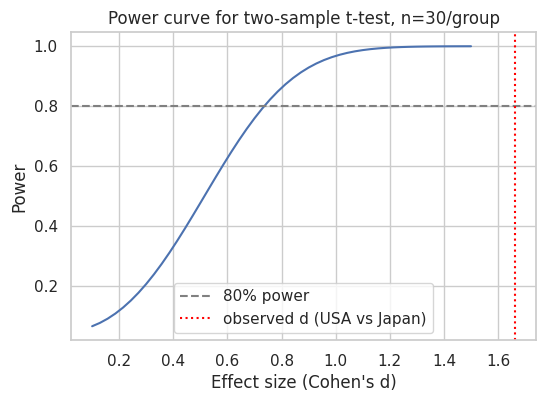

In [35]:
# Given the observed effect size between USA and Japan MPG, how large a sample
# would we need to reliably detect it with a two-sample t-test?
usa = mpg.loc[mpg.origin == 1, "mpg"].values
japan = mpg.loc[mpg.origin == 3, "mpg"].values

pooled_sd = np.sqrt((usa.var(ddof=1) + japan.var(ddof=1)) / 2)
observed_effect_size = abs(usa.mean() - japan.mean()) / pooled_sd
print(f"Observed Cohen's d (USA vs Japan MPG) = {observed_effect_size:.3f}")

power_calc_ind = TTestIndPower()
required_n_per_group = power_calc_ind.solve_power(observed_effect_size, power=0.80, alpha=0.05, ratio=1.0)
print(f"Sample size per group needed for 80% power: {required_n_per_group:.2f}")
print(f"(We actually have n_USA={len(usa)}, n_Japan={len(japan)} -- comfortably more than needed.)")

# Power curve
effect_sizes = np.linspace(0.1, 1.5, 50)
powers = [power_calc_ind.solve_power(es, nobs1=30, alpha=0.05, ratio=1.0) for es in effect_sizes]
plt.figure(figsize=(6, 4))
plt.plot(effect_sizes, powers)
plt.axhline(0.8, color="gray", linestyle="--", label="80% power")
plt.axvline(observed_effect_size, color="red", linestyle=":", label="observed d (USA vs Japan)")
plt.xlabel("Effect size (Cohen's d)")
plt.ylabel("Power")
plt.title("Power curve for two-sample t-test, n=30/group")
plt.legend()
plt.show()


**Try it yourself:** Suppose you only had 10 cars per origin group available (a much smaller study). Using the observed effect size above, what power would that give you? Would you be comfortable trusting a "fail to reject" result from a study that size?

In [36]:
# Try it yourself — Part E.2
# TODO: power_calc_ind.solve_power(observed_effect_size, nobs1=10, alpha=0.05, ratio=1.0)


---
## Part F — Capstone: Full Workflow

**Question:** Is there a significant difference in mean vehicle **weight** across the three `origin` groups (USA, Europe, Japan)?

Work through the *complete* pipeline: assumptions → test selection → test → effect size / post-hoc → plain-language interpretation. This mirrors what you'd do on a brand-new dataset in practice.


             mean       std  count
origin                            
1       3372.4898  795.3467    245
2       2433.4706  491.8139     68
3       2221.2278  320.4972     79


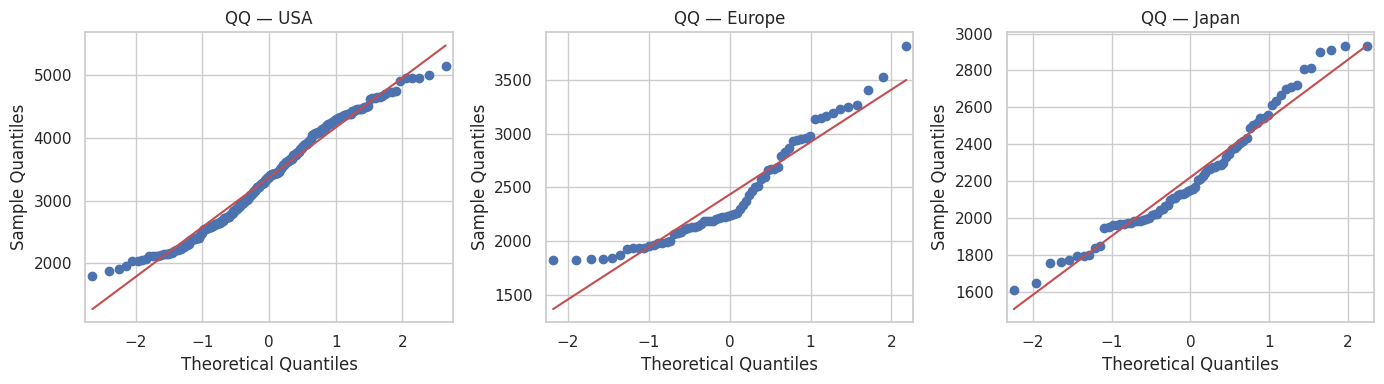

In [37]:
weight_1 = mpg.loc[mpg.origin == 1, "weight"]
weight_2 = mpg.loc[mpg.origin == 2, "weight"]
weight_3 = mpg.loc[mpg.origin == 3, "weight"]

print(mpg.groupby("origin")["weight"].agg(["mean", "std", "count"]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, sample) in zip(axes, [("USA", weight_1), ("Europe", weight_2), ("Japan", weight_3)]):
    sm.qqplot(sample, line="s", ax=ax)
    ax.set_title(f"QQ — {label}")
plt.tight_layout()
plt.show()


In [38]:
for label, sample in [("USA", weight_1), ("Europe", weight_2), ("Japan", weight_3)]:
    stat, p = stats.shapiro(sample)
    print(f"{label}: Shapiro-Wilk p-value = {p:.4f}")

f_stat, p_value = stats.levene(weight_1, weight_2, weight_3)
print(f"\nLevene's test across groups: F={f_stat:.4f}, p-value={p_value:.4f}")


USA: Shapiro-Wilk p-value = 0.0003
Europe: Shapiro-Wilk p-value = 0.0001
Japan: Shapiro-Wilk p-value = 0.0204

Levene's test across groups: F=42.7590, p-value=0.0000


In [39]:
# Decision: choose equal-variance or Welch's ANOVA based on the Levene's test result above,
# then run it, then follow up with Tukey's HSD if significant.
use_equal_var = p_value > 0.05  # from Levene's test just above
anova_result = anova_oneway(mpg.weight, mpg.origin, use_var="equal" if use_equal_var else "unequal")
print(f"Using {'equal-variance' if use_equal_var else 'Welch (unequal-variance)'} ANOVA:")
print(anova_result)


Using Welch (unequal-variance) ANOVA:
statistic = 173.46736627511083
pvalue = 6.295685995140273e-43
df = (2.0, np.float64(182.42482583628936))
df_num = 2.0
df_denom = 182.42482583628936
nobs_t = 392.0
n_groups = 3
means = [3372.48979592 2433.47058824 2221.2278481 ]
nobs = [245.  68.  79.]
vars_ = [632576.35747742 241880.87971905 102718.48588121]
use_var = unequal
welch_correction = True
tuple = (np.float64(173.46736627511083), np.float64(6.295685995140273e-43))


In [40]:
tukey_weight = pairwise_tukeyhsd(endog=mpg["weight"], groups=mpg["origin"], alpha=0.05)
print(tukey_weight)


    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------
     1      2  -939.0192    0.0 -1157.5085 -720.5299   True
     1      3 -1151.2619    0.0 -1357.5013 -945.0226   True
     2      3  -212.2427 0.1418  -475.9282   51.4427  False
-----------------------------------------------------------


**Interpretation (fill in for your own run):**
- Normality: were any groups flagged as non-normal? How much does that concern you given sample sizes?
- Equal variance: did Levene's test support pooling variances?
- ANOVA result: is there a significant difference in mean weight across origins?
- Tukey's HSD: which specific pairs differ, and by how much (in pounds)?
- Practical takeaway: is the difference large enough to matter for, say, fuel-economy regulation policy, or just statistically detectable given a large sample?

---
## Summary

You've now applied every test from Chapter 4 to both the book's original examples and to real automotive data, and extended the workflow with effect sizes, confidence intervals, and Tukey's HSD post-hoc testing. The next chapter in the book (non-parametric tests) covers what to do when these assumptions can't be defended even after transformation — see `06_background_theory.md` in this folder for a discussion of exactly where that line is and what these tests can/can't tell you.
